# Trajectory Plotting

Generates a presentation quality plot of the tracked particle trajectories.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# Apply presentation-quality formatting
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['figure.figsize'] = (6.5 * 0.8, (6.5 * 0.8) * (2/3)) # about 5.2 x 3.46
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 1.25

In [2]:
# Data file path
data_path = '../Data/2026-03-05/s2c-1um-0_5p-11_5ul-water-3978_5ul-gly-1000ul-trial3-tracker.txt'

# Load the data
# We'll skip the first 2 rows and specify the column names directly.
colnames = ['t', 'x_A', 'y_A', 'x_B', 'y_B', 'x_C', 'y_C']

df = pd.read_csv(data_path, sep='\t', skiprows=2, names=colnames)

# Drop the time column/NA blocks
columns_to_check = ['x_A', 'y_A', 'x_B', 'y_B', 'x_C', 'y_C']
df = df.dropna(how='all', subset=columns_to_check)
df.head()

,t,x_A,y_A,x_B,y_B,x_C,y_C


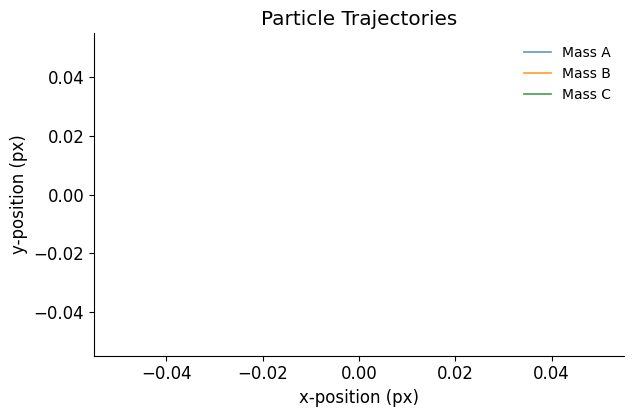

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.33)) # 3:2 ratio for full width

ax.plot(df['x_A'], df['y_A'], label='Mass A', color='steelblue', alpha=0.8)
ax.plot(df['x_B'], df['y_B'], label='Mass B', color='darkorange', alpha=0.8)
ax.plot(df['x_C'], df['y_C'], label='Mass C', color='forestgreen', alpha=0.8)

ax.set_xlabel('x-position (px)')
ax.set_ylabel('y-position (px)')
ax.set_title('Particle Trajectories')
ax.legend()

fig.tight_layout()
fig.savefig('particle_trajectories_presentation.png', dpi=300, bbox_inches='tight')
fig.savefig('particle_trajectories_presentation.pdf', bbox_inches='tight')

plt.show()